# 15. Most aplikacyjny: `grades.csv` i maratończycy

Ten notebook ma jeden cel: połączyć teorię z poprzednich modułów z danymi, które pojawiły się już wcześniej na zajęciach.

Nie zastępuje małych przykładów tablicowych. Ma pokazać, że te same pojęcia wracają w realniejszej analizie:

- design matrix,
- regresja liniowa,
- regresja logistyczna,
- odds i log-odds,
- train/test,
- ROC/AUC,
- threshold tuning,
- leakage,
- regularyzacja.

Najważniejsza dydaktyczna mantra:

$$
\text{mały przykład uczy mechanizmu, większy dataset uczy ostrożności.}
$$


## Jak czytać ten notebook?

To jest notebook **aplikacyjny**, czyli nie ma zastąpić krótkich przykładów tablicowych. Ma pokazać, że te same pojęcia wracają na danych:

1. `grades` — mały zbiór do przejścia z regresji liniowej do logistycznej,
2. `marathon` — większy zbiór do ROC/AUC, progu decyzyjnego, leakage i regularyzacji.

Jeśli coś jest niejasne, równoległe materiały w tym samym folderze:

- [08 — linear regression, $R^2$, $F$](08_linear_regression_lecture_v4_statquest_glm_executed.ipynb)
- [10 — odds, log-odds, odds ratio i testy](10_odds_log_odds_or_fisher_chisquare_wald_v6_statsmodels_free_executed.ipynb)
- [11 — logistic regression i likelihood](11_logistic_regression_likelihood_v6_executed.ipynb)
- [13 — ROC/AUC i threshold](13_roc_auc_thresholds_v6_executed.ipynb)
- [14 — regularization](14_regularization_ridge_lasso_elasticnet_v6_executed.ipynb)
- [99 — krótki companion: ROC, threshold, confusion matrix](99_companion_roc_threshold_toy_v6_5.ipynb)

Najważniejsza oś logiczna:

$$
\text{regresja liniowa} \rightarrow \text{target binarny} \rightarrow \text{logit} \rightarrow \text{ROC/AUC} \rightarrow \text{threshold}
$$

### Importy i ścieżki

W tej komórce ładujemy biblioteki oraz ustawiamy ścieżkę `DATA`. Jeśli notebook jest uruchomiony z folderu `notebooks`, dane powinny być w `../data`. Jeśli z katalogu głównego paczki, dane powinny być w `data`.

Najważniejsze importy:

- `train_test_split` — podział train/test,
- `LinearRegression` — regresja liniowa,
- `LogisticRegression` — regresja logistyczna,
- `roc_curve`, `roc_auc_score` — ROC i AUC,
- `StandardScaler` — standaryzacja cech przed modelem logistycznym/regularyzacją.

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression

pd.set_option('display.precision', 4)

DATA = Path('../data')
if not DATA.exists():
    DATA = Path('data')


## 1. Mały zbiór: godziny nauki i ocena

Ten zbiór jest dobry na początek, bo można go prawie cały przepisać na tablicę.

Dwa naturalne zadania:

1. Regresja liniowa, model:

$$
Grade = \beta_0 + \beta_1 StudyHours + \varepsilon
$$

2. Regresja logistyczna po zrobieniu zmiennej `Pass`:

$$
Pass=\mathbb{1}(Grade\ge 60)
$$

$$
\log\left(\frac{p}{1-p}\right)=\beta_0+\beta_1 StudyHours
$$


In [2]:
grades = pd.read_csv(DATA / 'previous_lecture_grades.csv')
grades = grades.dropna(subset=['StudyHours', 'Grade']).copy()
grades['Pass'] = (grades['Grade'] >= 60).astype(int)
grades.head(10)


,Name,StudyHours,Grade,Pass
0,Dan,10.00,50.0,0
1,Joann,11.50,50.0,0
2,Pedro,9.00,47.0,0
3,Rosie,16.00,97.0,1
4,Ethan,9.25,49.0,0
5,Vicky,1.00,3.0,0
6,Frederic,11.50,53.0,0
7,Jimmie,9.00,42.0,0
8,Rhonda,8.50,26.0,0
9,Giovanni,14.50,74.0,1


### 1.1. Regresja liniowa liczona przez design matrix

Macierz projektu dla modelu z interceptem i jedną cechą wygląda tak:

$$
X=
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
$$

Współczynniki OLS liczymy wzorem:

$$
\hat\beta=(X^TX)^{-1}X^Ty
$$

To jest dokładnie ta sama idea, która później wraca w t-teście, ANOVA i regresji logistycznej. Zmieniamy tylko funkcję celu i skalę interpretacji.


### Co dokładnie robi następna komórka?

Budujemy macierz projektu:

$$
X=\begin{bmatrix}
1 & StudyHours_1\\
1 & StudyHours_2\\
\vdots & \vdots
\end{bmatrix}
$$

Pierwsza kolumna jedynek to intercept $\beta_0$, druga kolumna to cecha `StudyHours`. Potem liczymy współczynniki OLS:

$$
\hat\beta=(X^TX)^{-1}X^Ty
$$

Na końcu mierzymy jakość:

- $R^2$ — poprawa względem baseline'u średniej,
- `MAE` — średni błąd w naturalnych jednostkach, czyli w punktach oceny.

In [3]:
# Macierz projektu: kolumna 1 = intercept, kolumna 2 = StudyHours
X = np.column_stack([np.ones(len(grades)), grades['StudyHours'].to_numpy()])
y = grades['Grade'].to_numpy()

# Wzór OLS: beta = (X^T X)^(-1) X^T y
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
# Predykcje modelu: y_hat = X beta
y_hat = X @ beta_hat

print(f"intercept beta0 = {beta_hat[0]:.3f}")
print(f"slope     beta1 = {beta_hat[1]:.3f} punktu oceny / godzina nauki")
print(f"R^2 = {r2_score(y, y_hat):.3f}")
print(f"MAE = {mean_absolute_error(y, y_hat):.3f}")


intercept beta0 = -11.522
slope     beta1 = 5.769 punktu oceny / godzina nauki
R^2 = 0.856
MAE = 6.600


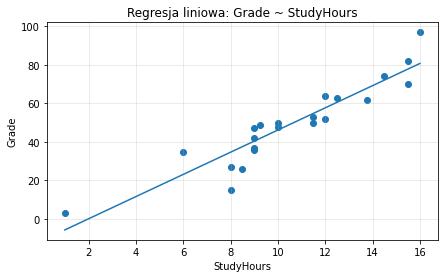

In [4]:
plt.figure(figsize=(7, 4))
plt.scatter(grades['StudyHours'], grades['Grade'])
xx = np.linspace(grades['StudyHours'].min(), grades['StudyHours'].max(), 100)
yy = beta_hat[0] + beta_hat[1] * xx
plt.plot(xx, yy)
plt.xlabel('StudyHours')
plt.ylabel('Grade')
plt.title('Regresja liniowa: Grade ~ StudyHours')
plt.grid(True, alpha=0.3)
plt.show()


### Komentarz do tablicy

Jeśli $\hat\beta_1\approx 6$, to model mówi: „jedna dodatkowa godzina nauki zwiększa przewidywaną ocenę o około 6 punktów”.

To nie znaczy, że jest to prawo natury. To znaczy, że w tych danych taka prosta minimalizuje sumę kwadratów błędów:

$$
SSE=\sum_i(y_i-\hat y_i)^2
$$


## 2. Ten sam zbiór jako problem klasyfikacji

Teraz cel jest binarny: `Pass` albo `Fail`.

Regresja liniowa nie jest naturalna, bo może przewidzieć wartości mniejsze niż 0 albo większe niż 1. Dlatego przechodzimy przez sekwencję:

$$
p \rightarrow odds=\frac{p}{1-p} \rightarrow \log(odds) \rightarrow \beta_0+\beta_1x \rightarrow p=\frac{1}{1+e^{-(\beta_0+\beta_1x)}}
$$

Na skali log-odds model jest liniowy:

$$
\log\left(\frac{p}{1-p}\right)=\beta_0+\beta_1 StudyHours
$$


In [5]:
grades[['Name', 'StudyHours', 'Grade', 'Pass']]


,Name,StudyHours,Grade,Pass
0,Dan,10.00,50.0,0
1,Joann,11.50,50.0,0
2,Pedro,9.00,47.0,0
3,Rosie,16.00,97.0,1
4,Ethan,9.25,49.0,0
5,Vicky,1.00,3.0,0
6,Frederic,11.50,53.0,0
7,Jimmie,9.00,42.0,0
8,Rhonda,8.50,26.0,0
9,Giovanni,14.50,74.0,1


### 2.1. Ręczne odds z prostej tabeli

Zróbmy brutalnie prosty podział:

- mniej niż 12 godzin nauki,
- co najmniej 12 godzin nauki.

Dla każdej grupy liczymy:

$$
odds=\frac{\#Pass}{\#Fail}
$$

A potem:

$$
OR=\frac{odds_{\ge 12h}}{odds_{<12h}}
$$

Gdy w którejś komórce jest zero, dodajemy małą korektę $0.5$, żeby dało się policzyć logarytmy. To jest tzw. korekta Haldane'a-Anscombe'a.


### Dlaczego dodajemy `0.5` do tabeli?

W tabeli może pojawić się zero, np. grupa `<12h` może mieć `0` osób, które zdały. Wtedy zwykłe odds:

$$
odds=\frac{Pass}{Fail}
$$

mogą być równe `0`, a odds ratio może być niestabilne albo nieskończone. Prosta poprawka Haldane'a-Anscombe'a dodaje `0.5` do każdej komórki. To nie jest „prawda biologiczna”, tylko stabilizacja rachunku dla małych tabel.

In [6]:
grades['StudyGroup'] = np.where(grades['StudyHours'] >= 12, '>=12h', '<12h')
tab = pd.crosstab(grades['StudyGroup'], grades['Pass'])
tab.columns = ['Fail', 'Pass']
print(tab)

# Poprawka Haldane'a-Anscombe'a: dodajemy 0.5,
# żeby uniknąć zer w małej tabeli 2x2.
corrected = tab + 0.5
odds_high = corrected.loc['>=12h', 'Pass'] / corrected.loc['>=12h', 'Fail']
odds_low = corrected.loc['<12h', 'Pass'] / corrected.loc['<12h', 'Fail']
OR = odds_high / odds_low
log_OR = math.log(OR)

print(f"odds(>=12h) = {odds_high:.3f}")
print(f"odds(<12h)  = {odds_low:.3f}")
print(f"OR          = {OR:.3f}")
print(f"log(OR)     = {log_OR:.3f}")


            Fail  Pass
StudyGroup            
<12h          14     0
>=12h          1     7
odds(>=12h) = 5.000
odds(<12h)  = 0.034
OR          = 145.000
log(OR)     = 4.977


### 2.2. Dopasowanie regresji logistycznej bez `statsmodels`

Poniżej używamy prostego Newtona/IRLS. Nie chodzi o „magiczny algorytm”, tylko o zobaczenie funkcji, którą maksymalizujemy.

Dla jednej obserwacji:

$$
P(y_i|p_i)=p_i^{y_i}(1-p_i)^{1-y_i}
$$

Dla całego zbioru:

$$
L(\beta)=\prod_i p_i^{y_i}(1-p_i)^{1-y_i}
$$

W praktyce maksymalizujemy log-likelihood:

$$
\ell(\beta)=\sum_i \left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right]
$$


### Co robi IRLS/Newton w regresji logistycznej?

Regresja logistyczna nie minimalizuje $SSE$. Ona maksymalizuje log-likelihood:

$$
\ell(\beta)=\sum_i y_i\log(p_i)+(1-y_i)\log(1-p_i)
$$

Funkcja `fit_logistic_irls` iteracyjnie poprawia parametry $\beta$, aż log-likelihood przestaje się istotnie zmieniać. W tym notebooku to jest wersja dydaktyczna, żeby pokazać mechanizm. W praktyce zwykle używamy `sklearn.LogisticRegression`.

In [7]:
def fit_logistic_irls(X, y, max_iter=100, tol=1e-9, ridge=1e-6):
    """Simple IRLS/Newton optimizer for teaching. Adds tiny ridge for numerical stability."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    beta = np.zeros(X.shape[1])
    I = np.eye(X.shape[1])
    I[0, 0] = 0  # do not penalize intercept
    for _ in range(max_iter):
        eta = X @ beta
        p = expit(eta)
        W = p * (1 - p)
        grad = X.T @ (y - p) - ridge * (I @ beta)
        H = -(X.T * W) @ X - ridge * I
        step = np.linalg.solve(H, grad)
        beta_new = beta - step
        if np.max(np.abs(beta_new - beta)) < tol:
            beta = beta_new
            break
        beta = beta_new
    return beta

def log_likelihood(X, y, beta):
    eta = X @ beta
    p = expit(eta)
    eps = 1e-12
    return float(np.sum(y * np.log(p + eps) + (1-y) * np.log(1-p + eps)))

X_log = np.column_stack([np.ones(len(grades)), grades['StudyHours'].to_numpy()])
y_log = grades['Pass'].to_numpy()

beta_log = fit_logistic_irls(X_log, y_log, ridge=1e-4)
print(f"beta0 = {beta_log[0]:.3f}")
print(f"beta1 = {beta_log[1]:.3f}")
print(f"exp(beta1) = {math.exp(beta_log[1]):.3f}")
print(f"log-likelihood = {log_likelihood(X_log, y_log, beta_log):.3f}")


beta0 = -167.481
beta1 = 13.957
exp(beta1) = 1151540.560
log-likelihood = -1.389


Interpretacja:

- $\beta_1$ mówi, o ile zmienia się log-odds zaliczenia po dodaniu jednej godziny nauki.
- $e^{\beta_1}$ mówi, ile razy mnożą się odds zaliczenia po dodaniu jednej godziny.

Jeżeli $e^{\beta_1}=2$, to jedna dodatkowa godzina podwaja odds zaliczenia. To nie jest to samo co podwojenie prawdopodobieństwa.


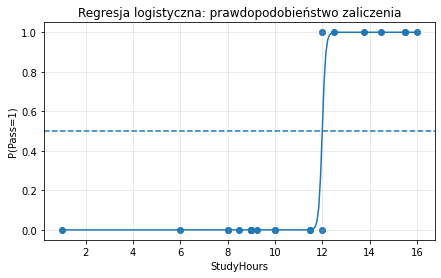

Próg p=0.5 wypada przy StudyHours ≈ 12.00


In [8]:
xx = np.linspace(grades['StudyHours'].min(), grades['StudyHours'].max(), 200)
pp = expit(beta_log[0] + beta_log[1] * xx)

plt.figure(figsize=(7, 4))
plt.scatter(grades['StudyHours'], grades['Pass'])
plt.plot(xx, pp)
plt.axhline(0.5, linestyle='--')
plt.xlabel('StudyHours')
plt.ylabel('P(Pass=1)')
plt.title('Regresja logistyczna: prawdopodobieństwo zaliczenia')
plt.grid(True, alpha=0.3)
plt.show()

# threshold where p=0.5 => beta0 + beta1*x = 0
x_threshold = -beta_log[0] / beta_log[1]
print(f"Próg p=0.5 wypada przy StudyHours ≈ {x_threshold:.2f}")


## 3. Większy zbiór: maratończycy

Teraz przechodzimy do danych, na których da się pokazać prawdziwy pipeline.

Dane mają cztery oryginalne kolumny:

- `age`,
- `gender`,
- `split`, czyli czas półmetka,
- `final`, czyli czas końcowy.

Po przetworzeniu mamy m.in.:

- `split_hours`,
- `final_hours`,
- `female`,
- `under_4h`.

Dydaktycznie to jest świetne, bo możemy zapytać:

> Czy na półmetku da się przewidzieć, kto ukończy maraton poniżej 4 godzin?

To jest naturalny problem regresji logistycznej.


### Jak rozumieć dane maratońskie?

Najważniejsze kolumny:

- `split_hours` — czas półmetka w godzinach,
- `final_hours` — czas końcowy w godzinach,
- `female` — zakodowana płeć; `1` dla kobiet, `0` dla mężczyzn,
- `under_4h` — target binarny: czy wynik poniżej 4 godzin,
- `slowdown_minutes` — o ile druga połowa była wolniejsza od pierwszej.

To są dobre dane, bo z jednego zbioru można zrobić i regresję, i klasyfikację.

In [9]:
marathon = pd.read_csv(DATA / 'previous_lecture_marathon_processed_sample.csv')
marathon[['age', 'gender', 'split', 'final', 'split_hours', 'final_hours', 'female', 'under_4h', 'slowdown_minutes']].head()


,age,gender,split,final,split_hours,final_hours,female,under_4h,slowdown_minutes
0,31,M,01:06:32,02:13:59,1.1089,2.2331,0,1,0.9167
1,24,M,01:09:16,02:19:45,1.1544,2.3292,0,1,1.2167
2,30,M,01:11:51,02:26:15,1.1975,2.4375,0,1,2.5500
3,36,W,01:12:57,02:28:13,1.2158,2.4703,1,1,2.3167
4,33,M,01:13:40,02:29:52,1.2278,2.4978,0,1,2.5333


In [10]:
summary = marathon[['age', 'split_hours', 'final_hours', 'slowdown_minutes', 'under_4h']].describe().T
summary


,count,mean,std,min,25%,50%,75%,max
age,5000.0,40.8802,10.1740,17.0000,33.0000,40.0000,48.0000,80.0000
split_hours,5000.0,2.0667,0.3828,1.1089,1.8039,2.0193,2.2678,4.9969
final_hours,5000.0,4.8082,1.0657,2.2331,4.0332,4.7372,5.4710,10.0189
slowdown_minutes,5000.0,40.4901,24.0957,-30.6167,21.9792,39.4083,56.9417,174.7667
under_4h,5000.0,0.2394,0.4268,0.0000,0.0000,0.0000,0.0000,1.0000


## 4. Regresja liniowa: przewidywanie czasu końcowego

Najpierw problem regresyjny:

$$
final\_hours = \beta_0 + \beta_1 split\_hours + \beta_2 age + \beta_3 female + \varepsilon
$$

To jest dobre ćwiczenie przed logistyczną, bo pokazuje pełny pipeline, ale cel nadal jest ciągły.


### Pipeline regresji liniowej na maratonie

Pytanie regresyjne:

> Czy na podstawie wieku, płci i czasu półmetka umiemy przewidzieć czas końcowy?

Używamy tylko cech dostępnych na półmetku. To ważne, bo `final_hours` byłoby odpowiedzią, a nie uczciwą cechą.

Metryki:

- `MAE_hours` — średni błąd w godzinach,
- `RMSE_hours` — mocniej karze duże błędy,
- `R2` — porównanie z baseline'em średniego czasu końcowego.

In [11]:
features = ['split_hours', 'age', 'female']
target_reg = 'final_hours'

X = marathon[features]
y = marathon[target_reg]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

pred_train = lin_model.predict(X_train)
pred_test = lin_model.predict(X_test)

metrics_reg = pd.DataFrame({
    'split': ['train', 'test'],
    'MAE_hours': [mean_absolute_error(y_train, pred_train), mean_absolute_error(y_test, pred_test)],
    'RMSE_hours': [math.sqrt(mean_squared_error(y_train, pred_train)), math.sqrt(mean_squared_error(y_test, pred_test))],
    'R2': [r2_score(y_train, pred_train), r2_score(y_test, pred_test)],
})
metrics_reg


,split,MAE_hours,RMSE_hours,R2
0,train,0.2377,0.3136,0.9112
1,test,0.2321,0.3009,0.9258


In [12]:
coefs = pd.Series(lin_model.coef_, index=features)
print(f"intercept = {lin_model.intercept_:.3f}")
print(coefs)


intercept = -0.663
split_hours    2.6824
age           -0.0013
female        -0.0441
dtype: float64


### Komentarz do interpretacji

Najważniejsza cecha to zwykle `split_hours`, bo czas na półmetku silnie ogranicza możliwy czas końcowy.

Współczynnik przy `age` mówi: o ile godzin zmienia się przewidywany czas końcowy przy wzroście wieku o 1 rok, przy stałym czasie półmetka i płci.

Współczynnik przy `female` mówi: o ile zmienia się przewidywany czas dla `female=1` względem `female=0`, przy tym samym `split_hours` i `age`.

Tu można przypomnieć bardzo ważne zdanie:

$$
\text{współczynnik opisuje zmianę przy pozostałych cechach trzymanych stało.}
$$


## 5. Regresja logistyczna: czy zawodnik złamie 4 godziny?

Teraz target jest binarny:

$$
under\_4h=\begin{cases}
1, & final\_hours \le 4 \\
0, & final\_hours > 4
\end{cases}
$$

Model:

$$
\log\left(\frac{p}{1-p}\right)=\beta_0+\beta_1 split\_hours+\beta_2 age+\beta_3 female
$$

Ważne: model zwraca prawdopodobieństwo $\hat p$, a klasa pojawia się dopiero po wyborze progu.


### Pipeline regresji logistycznej na maratonie

Teraz pytanie jest binarne:

$$
under\_4h = I(final\_hours < 4)
$$

Model zwraca prawdopodobieństwo:

$$
\hat p=P(under\_4h=1|X)
$$

Nie zamieniamy go od razu na klasę. Najpierw sprawdzamy ranking przez AUC, a dopiero potem wybieramy threshold.

In [13]:
X = marathon[features]
y = marathon['under_4h']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

logit_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='lbfgs', max_iter=2000)
)
logit_model.fit(X_train, y_train)

# predict_proba(... )[:, 1] = prawdopodobieństwo klasy pozytywnej: under_4h=1
p_train = logit_model.predict_proba(X_train)[:, 1]
p_test = logit_model.predict_proba(X_test)[:, 1]

print(f"AUC train = {roc_auc_score(y_train, p_train):.3f}")
print(f"AUC test  = {roc_auc_score(y_test, p_test):.3f}")
print(f"Baseline rate under_4h test = {y_test.mean():.3f}")


AUC train = 0.983
AUC test  = 0.987
Baseline rate under_4h test = 0.239


### Jak czytać wykres ROC?

Każdy punkt krzywej ROC odpowiada innemu progowi `threshold`.

- Oś X: $FPR=FP/(FP+TN)$ — odsetek fałszywych alarmów.
- Oś Y: $TPR=TP/(TP+FN)$ — odsetek wykrytych pozytywów, czyli recall/czułość.

Krzywa blisko lewego górnego rogu oznacza dobry ranking. AUC bliskie `1` oznacza, że model prawie zawsze daje wyższy score zawodnikowi `under_4h` niż zawodnikowi `not_under_4h`.

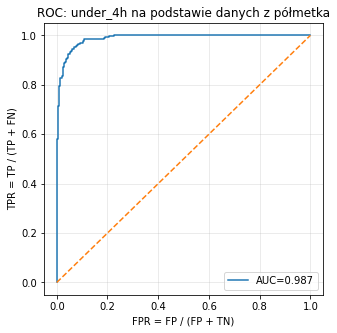

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, p_test)
auc = roc_auc_score(y_test, p_test)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('FPR = FP / (FP + TN)')
plt.ylabel('TPR = TP / (TP + FN)')
plt.title('ROC: under_4h na podstawie danych z półmetka')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 5.1. Threshold tuning

AUC nie wybiera progu. AUC odpowiada na pytanie: „czy model dobrze porządkuje przypadki?”.

Decyzja operacyjna wymaga progu:

$$
\hat y=\begin{cases}
1, & \hat p \ge threshold \\
0, & \hat p < threshold
\end{cases}
$$

Różne progi dają różne kompromisy między precision i recall.


### Co pokazuje tabela progów?

AUC mówi o rankingu, ale decyzja operacyjna wymaga progu:

$$
\hat y = I(\hat p \ge threshold)
$$

Niski threshold oznacza model „agresywny”: wykrywa więcej pozytywów, ale robi więcej false positives. Wysoki threshold oznacza model „ostrożny”: mniej false positives, ale więcej false negatives.

In [15]:
def threshold_metrics(y_true, scores, thresholds):
    rows = []
    for t in thresholds:
        # Threshold zamienia probability/score na klasę 0/1
        pred = (scores >= t).astype(int)
        # confusion_matrix zwraca [[TN, FP], [FN, TP]]
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        rows.append({
            'threshold': t,
            'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall_TPR': recall_score(y_true, pred, zero_division=0),
            'FPR': fp / (fp + tn) if (fp + tn) else np.nan,
            'F1': f1_score(y_true, pred, zero_division=0),
        })
    return pd.DataFrame(rows)

threshold_table = threshold_metrics(y_test.to_numpy(), p_test, [0.1, 0.2, 0.3, 0.5, 0.7, 0.9])
threshold_table


,threshold,TP,FP,TN,FN,precision,recall_TPR,FPR,F1
0,0.1,294,134,817,5,0.6869,0.9833,0.1409,0.8088
1,0.2,290,89,862,9,0.7652,0.9699,0.0936,0.8555
2,0.3,285,65,886,14,0.8143,0.9532,0.0683,0.8783
3,0.5,266,32,919,33,0.8926,0.8896,0.0336,0.8911
4,0.7,244,14,937,55,0.9457,0.8161,0.0147,0.8761
5,0.9,175,3,948,124,0.9831,0.5853,0.0032,0.7338


### 5.2. Macierz pomyłek krok po kroku

Macierz pomyłek powstaje dopiero wtedy, gdy zamienimy prawdopodobieństwa na klasy.

Model daje score:

$$
\hat p = P(under\_4h=1 \mid X)
$$

Wybieramy próg, np. `threshold = 0.5`, i robimy decyzję:

$$
\hat y =
\begin{cases}
1, & \hat p \ge 0.5 \\
0, & \hat p < 0.5
\end{cases}
$$

Dopiero potem porównujemy:

- `y_true` — prawdziwa odpowiedź,
- `y_pred` — decyzja modelu po progu.

In [16]:
threshold_cm = 0.5

# 1) Zamieniamy prawdopodobieństwa na decyzje 0/1.
pred_test_cm = (p_test >= threshold_cm).astype(int)

# 2) Pokazujemy kilka pierwszych przypadków: prawda, probability i decyzja.
cm_examples = pd.DataFrame({
    'y_true': y_test.to_numpy(),
    'p_hat': p_test,
    'y_pred': pred_test_cm,
})

cm_examples['opis'] = np.select(
    [
        (cm_examples['y_true'] == 0) & (cm_examples['y_pred'] == 0),
        (cm_examples['y_true'] == 0) & (cm_examples['y_pred'] == 1),
        (cm_examples['y_true'] == 1) & (cm_examples['y_pred'] == 0),
        (cm_examples['y_true'] == 1) & (cm_examples['y_pred'] == 1),
    ],
    [
        'TN: dobrze przewidziano >4h',
        'FP: fałszywy alarm under_4h',
        'FN: przegapiono under_4h',
        'TP: dobrze przewidziano under_4h',
    ],
)

cm_examples.head(12)

,y_true,p_hat,y_pred,opis
0,0,2.5727e-03,0,TN: dobrze przewidziano >4h
1,0,3.2099e-04,0,TN: dobrze przewidziano >4h
2,0,1.4277e-07,0,TN: dobrze przewidziano >4h
3,0,6.0582e-06,0,TN: dobrze przewidziano >4h
4,1,9.5050e-01,1,TP: dobrze przewidziano under_4h
5,0,1.3140e-05,0,TN: dobrze przewidziano >4h
6,0,2.6807e-03,0,TN: dobrze przewidziano >4h
7,0,7.9110e-04,0,TN: dobrze przewidziano >4h
8,1,8.8716e-01,1,TP: dobrze przewidziano under_4h
9,1,9.9871e-01,1,TP: dobrze przewidziano under_4h


Teraz zliczamy cztery typy przypadków.

Dla targetu `under_4h` klasą pozytywną jest `1`, czyli zawodnik kończy poniżej 4 godzin.

| Nazwa | Warunek | Znaczenie |
|---|---|---|
| TN | `y_true=0`, `y_pred=0` | model poprawnie mówi: nie poniżej 4h |
| FP | `y_true=0`, `y_pred=1` | model mówi: poniżej 4h, ale to fałszywy alarm |
| FN | `y_true=1`, `y_pred=0` | model przegapia zawodnika poniżej 4h |
| TP | `y_true=1`, `y_pred=1` | model poprawnie mówi: poniżej 4h |

In [17]:
y_true_cm = y_test.to_numpy()

manual_counts = pd.DataFrame({
    'komórka': ['TN', 'FP', 'FN', 'TP'],
    'warunek': [
        'y_true=0 i y_pred=0',
        'y_true=0 i y_pred=1',
        'y_true=1 i y_pred=0',
        'y_true=1 i y_pred=1',
    ],
    'liczba': [
        int(((y_true_cm == 0) & (pred_test_cm == 0)).sum()),
        int(((y_true_cm == 0) & (pred_test_cm == 1)).sum()),
        int(((y_true_cm == 1) & (pred_test_cm == 0)).sum()),
        int(((y_true_cm == 1) & (pred_test_cm == 1)).sum()),
    ]
})

manual_counts

,komórka,warunek,liczba
0,TN,y_true=0 i y_pred=0,919
1,FP,y_true=0 i y_pred=1,32
2,FN,y_true=1 i y_pred=0,33
3,TP,y_true=1 i y_pred=1,266


In [18]:
# To samo w formie macierzy.
# sklearn zwraca układ: [[TN, FP],
#                       [FN, TP]]
cm = confusion_matrix(y_test, pred_test_cm, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=['Naprawdę: >4h albo =4h (0)', 'Naprawdę: under_4h (1)'],
    columns=['Przewidziano: >4h albo =4h (0)', 'Przewidziano: under_4h (1)']
)

cm_df

,Przewidziano: >4h albo =4h (0),Przewidziano: under_4h (1)
Naprawdę: >4h albo =4h (0),919,32
Naprawdę: under_4h (1),33,266


In [19]:
tn, fp, fn, tp = cm.ravel()

print(f"threshold = {threshold_cm}")
print(f"TN = {tn}: model mówi 0 i naprawdę jest 0")
print(f"FP = {fp}: model mówi 1, ale naprawdę jest 0")
print(f"FN = {fn}: model mówi 0, ale naprawdę jest 1")
print(f"TP = {tp}: model mówi 1 i naprawdę jest 1")
print()
print(f"accuracy  = {(tp + tn) / cm.sum():.3f}")
print(f"precision = {tp / (tp + fp):.3f}" if (tp + fp) else "precision = undefined")
print(f"recall    = {tp / (tp + fn):.3f}" if (tp + fn) else "recall = undefined")

threshold = 0.5
TN = 919: model mówi 0 i naprawdę jest 0
FP = 32: model mówi 1, ale naprawdę jest 0
FN = 33: model mówi 0, ale naprawdę jest 1
TP = 266: model mówi 1 i naprawdę jest 1

accuracy  = 0.948
precision = 0.893
recall    = 0.890


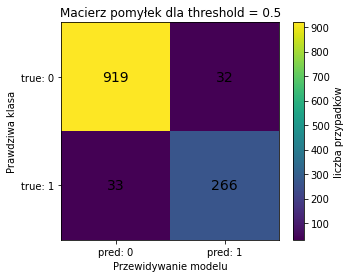

In [20]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

plt.xticks([0, 1], ['pred: 0', 'pred: 1'])
plt.yticks([0, 1], ['true: 0', 'true: 1'])
plt.xlabel('Przewidywanie modelu')
plt.ylabel('Prawdziwa klasa')
plt.title('Macierz pomyłek dla threshold = 0.5')
plt.colorbar(label='liczba przypadków')
plt.show()

### 5.3. Od prawdopodobieństwa do odds i log-odds

Regresja logistyczna nie modeluje prawdopodobieństwa liniowo. Liniowa jest skala log-odds:

$$
odds = \frac{p}{1-p}
$$

$$
\log(odds)=\log\left(\frac{p}{1-p}\right)
$$

Najprostsza intuicja:

- przy `p = 0.5` mamy `odds = 1`, więc `log(odds) = 0`,
- przy `p > 0.5` log-odds są dodatnie,
- przy `p < 0.5` log-odds są ujemne.

In [21]:
p_demo = np.array([0.01, 0.05, 0.10, 0.20, 0.50, 0.80, 0.90, 0.95, 0.99])
odds_demo = p_demo / (1 - p_demo)
log_odds_demo = np.log(odds_demo)

pd.DataFrame({
    'p': p_demo,
    'odds = p/(1-p)': odds_demo,
    'log(odds)': log_odds_demo,
})

,p,odds = p/(1-p),log(odds)
0,0.01,0.0101,-4.5951
1,0.05,0.0526,-2.9444
2,0.10,0.1111,-2.1972
3,0.20,0.2500,-1.3863
4,0.50,1.0000,0.0000
5,0.80,4.0000,1.3863
6,0.90,9.0000,2.1972
7,0.95,19.0000,2.9444
8,0.99,99.0000,4.5951


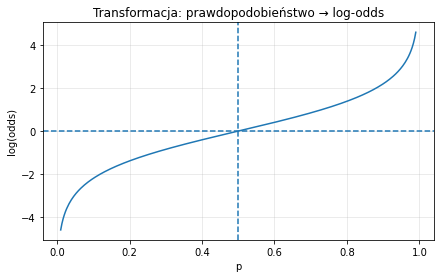

In [22]:
p_grid = np.linspace(0.01, 0.99, 300)
log_odds_grid = np.log(p_grid / (1 - p_grid))

plt.figure(figsize=(7, 4))
plt.plot(p_grid, log_odds_grid)
plt.axhline(0, linestyle='--')
plt.axvline(0.5, linestyle='--')
plt.xlabel('p')
plt.ylabel('log(odds)')
plt.title('Transformacja: prawdopodobieństwo → log-odds')
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# Log-odds dla prawdopodobieństw przewidzianych przez nasz model maratoński.
eps = 1e-9
p_safe = np.clip(p_test, eps, 1 - eps)

model_odds = p_safe / (1 - p_safe)
model_log_odds = np.log(model_odds)

pd.DataFrame({
    'p_hat': p_test,
    'odds': model_odds,
    'log_odds': model_log_odds,
    'y_true': y_test.to_numpy(),
}).sort_values('p_hat').head(10)

,p_hat,odds,log_odds,y_true
655,1.0747e-20,1.0000e-09,-20.7233,0
311,3.0539e-16,1.0000e-09,-20.7233,0
176,2.2893e-15,1.0000e-09,-20.7233,0
1021,5.4086e-15,1.0000e-09,-20.7233,0
728,8.5777e-15,1.0000e-09,-20.7233,0
422,3.7148e-14,1.0000e-09,-20.7233,0
1085,4.4211e-14,1.0000e-09,-20.7233,0
646,5.0163e-14,1.0000e-09,-20.7233,0
87,1.2590e-13,1.0000e-09,-20.7233,0
334,3.4974e-13,1.0000e-09,-20.7233,0


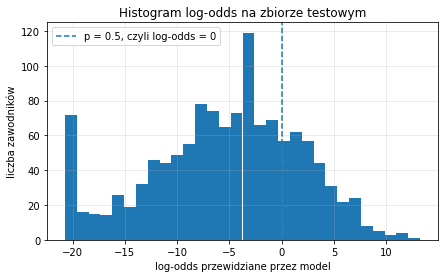

In [24]:
plt.figure(figsize=(7, 4))
plt.hist(model_log_odds, bins=30)
plt.axvline(0, linestyle='--', label='p = 0.5, czyli log-odds = 0')
plt.xlabel('log-odds przewidziane przez model')
plt.ylabel('liczba zawodników')
plt.title('Histogram log-odds na zbiorze testowym')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.4. Histogram sum 100 prób i rozkład normalny

Teraz osobny, bardzo intuicyjny most do rozkładu normalnego.

Wyobraźmy sobie 100 niezależnych prób typu `0/1`:

- `1` = sukces,
- `0` = porażka.

W jednej serii liczymy sumę:

$$
S = y_1+y_2+\ldots+y_{100}
$$

Ta suma mówi, ile sukcesów było w 100 próbach. Gdy powtarzamy taki eksperyment wiele razy, histogram sum zaczyna mieć kształt podobny do rozkładu normalnego.

Dla prób Bernoulliego:

$$
E(S)=np
$$

$$
SD(S)=\sqrt{np(1-p)}
$$

In [25]:
rng = np.random.default_rng(42)

n_trials = 100       # w każdej serii sumujemy 100 liczb 0/1
p_success = 0.60     # prawdopodobieństwo sukcesu w jednej próbie
n_series = 10_000    # liczba powtórzeń eksperymentu

# Macierz 10_000 x 100: każdy wiersz to jedna seria 100 prób.
simulated_zeros_ones = rng.binomial(n=1, p=p_success, size=(n_series, n_trials))

# Suma w wierszu = liczba sukcesów w 100 próbach.
success_sums = simulated_zeros_ones.sum(axis=1)

pd.DataFrame({
    'seria': np.arange(1, 11),
    'suma_sukcesów_z_100': success_sums[:10],
    'suma_porażek_z_100': n_trials - success_sums[:10],
})

,seria,suma_sukcesów_z_100,suma_porażek_z_100
0,1,60,40
1,2,63,37
2,3,62,38
3,4,59,41
4,5,56,44
5,6,61,39
6,7,54,46
7,8,67,33
8,9,59,41
9,10,62,38


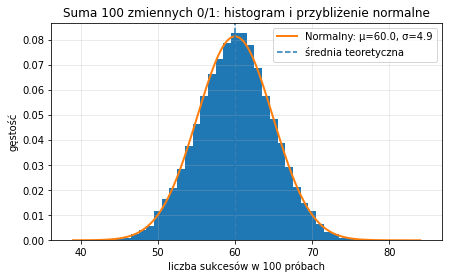

In [26]:
mu = n_trials * p_success
sigma = math.sqrt(n_trials * p_success * (1 - p_success))

x_norm = np.linspace(success_sums.min(), success_sums.max(), 400)
normal_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x_norm - mu) / sigma) ** 2
)

plt.figure(figsize=(7, 4))
plt.hist(success_sums, bins=np.arange(success_sums.min(), success_sums.max() + 2) - 0.5, density=True)
plt.plot(x_norm, normal_pdf, linewidth=2, label=f'Normalny: μ={mu:.1f}, σ={sigma:.1f}')
plt.axvline(mu, linestyle='--', label='średnia teoretyczna')
plt.xlabel('liczba sukcesów w 100 próbach')
plt.ylabel('gęstość')
plt.title('Suma 100 zmiennych 0/1: histogram i przybliżenie normalne')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Najważniejszy komentarz dydaktyczny:

> Pojedynczy wynik `0/1` nie jest normalny.  
> Ale suma wielu niezależnych wyników `0/1` często wygląda prawie normalnie.

To jest intuicja stojąca za centralnym twierdzeniem granicznym. W praktyce dlatego histogramy średnich lub sum często mają „dzwonowy” kształt, nawet jeśli pojedyncze obserwacje nie są normalne.

### Komentarz do prowadzenia

- Próg $0.1$ zwykle łapie więcej prawdziwych przypadków pozytywnych, ale robi więcej false positives.
- Próg $0.9$ jest bardzo ostrożny: mniej osób oznacza jako pozytywne, ale może przegapić wiele prawdziwych sukcesów.
- Próg $0.5$ nie jest święty. Jest tylko domyślnym punktem startowym.

To jest bardzo ważne przed późniejszą kalibracją i model selection.


## 6. Leakage: model wie coś, czego nie powinien wiedzieć

Teraz celowo robimy zły przykład.

Target `under_4h` jest zdefiniowany przez `final_hours`. Jeśli użyjemy `final_hours` jako cechy, model dostaje odpowiedź w przebraniu.

Zły model:

$$
under\_4h \sim split\_hours + age + female + final\_hours
$$

To nie jest uczciwa predykcja na półmetku maratonu.


### Dlaczego to jest leakage?

Target jest zdefiniowany jako:

$$
under\_4h = I(final\_hours < 4)
$$

Jeśli dodamy `final_hours` jako cechę, model dostaje odpowiedź wprost. Metryka będzie świetna, ale model nie jest uczciwy, bo na półmetku nie znamy jeszcze czasu końcowego.

In [27]:
features_leaky = ['split_hours', 'age', 'female', 'final_hours']
X_bad = marathon[features_leaky]
y = marathon['under_4h']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bad, y, test_size=0.25, random_state=42, stratify=y
)

bad_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='lbfgs', max_iter=2000)
)
bad_model.fit(X_train_b, y_train_b)
p_bad = bad_model.predict_proba(X_test_b)[:, 1]

print(f"AUC uczciwy model = {roc_auc_score(y_test, p_test):.3f}")
print(f"AUC model z leakage = {roc_auc_score(y_test_b, p_bad):.3f}")


AUC uczciwy model = 0.987
AUC model z leakage = 1.000


### Pytanie do studentów

Czy model z leakage jest „lepszy”?

Technicznie metryka jest lepsza. Dydaktycznie i metodologicznie model jest gorszy, bo narusza warunek:

$$
\text{cechy muszą być dostępne w momencie predykcji.}
$$

Na półmetku maratonu nie znamy jeszcze `final_hours`.


## 6.1. Kontrprzykład: słabe cechy dają słaby ROC

Wcześniej model miał bardzo wysokie AUC, bo używał `split_hours`. To jest ekstremalnie mocna cecha: czas półmetka silnie porządkuje zawodników względem czasu końcowego.

Teraz robimy kontrprzykład: używamy tylko słabszych cech:

```python
features = ['age', 'female']
```

Następnie skanujemy różne progi czasu końcowego, np. `final_hours < 4.65`, i sprawdzamy, dla którego progu model najgorzej rozdziela klasy. Chodzi o pokazanie:

> jakość cech jest często ważniejsza niż sam algorytm.

In [28]:
# Kontrprzykład: używamy tylko słabych cech.
# Bez split_hours model ma dużo mniej informacji o wyniku końcowym.
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

# Celowo słabe cechy: wiek i płeć.
# Dla porównania możesz odkomentować split_hours i zobaczyć, jak AUC rośnie.
features = ['age', 'female']
# features = ['split_hours', 'age', 'female']

rows = []

# Skanujemy wiele progów typu: czy final_hours < cutoff?
# Szukamy takiego progu, dla którego słabe cechy najgorzej porządkują klasy.
for cutoff in np.arange(2.5, 6.0, 0.05):
    y = (marathon['final_hours'] < cutoff).astype(int)

    # Pomijamy skrajnie rzadkie targety, bo AUC przy bardzo małych klasach
    # może być niestabilne i mniej dydaktyczne.
    if y.sum() < 30 or (len(y) - y.sum()) < 30:
        continue

    X = marathon[features]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000)
    )

    model.fit(X_train, y_train)
    p_test = model.predict_proba(X_test)[:, 1]

    rows.append({
        'cutoff_hours': cutoff,
        'positive_rate': y.mean(),
        'AUC': roc_auc_score(y_test, p_test)
    })

scan = pd.DataFrame(rows).sort_values('AUC')
scan.head(10)

,cutoff_hours,positive_rate,AUC
38,4.65,0.4646,0.6245
14,3.45,0.0976,0.6258
39,4.70,0.4832,0.6286
37,4.60,0.4456,0.6296
35,4.50,0.4084,0.6300
25,4.00,0.2394,0.6303
22,3.85,0.1958,0.6304
29,4.20,0.2972,0.6329
42,4.85,0.5410,0.6335
47,5.10,0.6280,0.6350


### Wybieramy najgorszy cutoff

`scan` jest posortowany rosnąco po AUC, więc pierwszy wiersz to próg, dla którego model na cechach `age` i `female` radzi sobie najsłabiej.

In [29]:
bad_cutoff = scan.iloc[0]['cutoff_hours']
bad_cutoff

4.649999999999992

### Model dla wybranego trudnego progu

Teraz ponownie dopasowujemy model dla jednego progu `bad_cutoff`, żeby narysować ROC i pokazać słaby ranking.

Jeśli AUC jest blisko `0.5`, model jest prawie losowy. Jeśli np. `0.62`, model ma tylko niewielką przewagę nad losowością.

In [30]:
y = (marathon['final_hours'] < bad_cutoff).astype(int)
X = marathon[features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

model.fit(X_train, y_train)
p_test = model.predict_proba(X_test)[:, 1]

print("cutoff:", bad_cutoff)
print("positive rate:", y.mean())
print("AUC:", roc_auc_score(y_test, p_test))

cutoff: 4.649999999999992
positive rate: 0.4646
AUC: 0.6244503960750112


### Interpretacja słabego ROC

Jeśli krzywa ROC leży blisko przekątnej, model nie umie dobrze porządkować zawodników. To nie znaczy, że `LogisticRegression` jest zły. To znaczy, że cechy `age` i `female` nie niosą wystarczającej informacji o czasie końcowym.

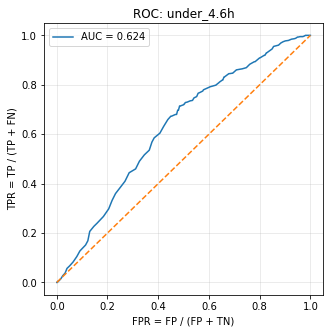

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, p_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))

# ROC modelu
plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

# model losowy
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('FPR = FP / (FP + TN)')
plt.ylabel('TPR = TP / (TP + FN)')

plt.title(f'ROC: under_{bad_cutoff:.1f}h')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Zanim przejdziemy do regularyzacji

Regularizacja nie naprawia braku informacji w cechach. Jej rola jest inna:

- ogranicza zbyt duże współczynniki,
- stabilizuje model,
- przy L1 może wyzerować część cech,
- pomaga przy wielu cechach i interakcjach.

W `sklearn` parametr `C` działa odwrotnie do siły kary: mniejsze `C` oznacza silniejszą regularizację.

## 7. Regularizacja na danych maratończyków

Regularyzacja jest najbardziej naturalna, gdy mamy dużo cech, interakcje albo cechy skorelowane.

Zrobimy cechy wielomianowe stopnia 3, a potem porównamy L2 i L1.

L2/Ridge:

$$
Loss(\beta)+\lambda\sum_j\beta_j^2
$$

L1/Lasso:

$$
Loss(\beta)+\lambda\sum_j|\beta_j|
$$

W `sklearn` dla regresji logistycznej parametr `C` jest odwrotnością siły regularyzacji:

$$
C \uparrow \Rightarrow \text{słabsza regularyzacja}
$$

$$
C \downarrow \Rightarrow \text{silniejsza regularyzacja}
$$


In [32]:
base_features = ['split_hours', 'age', 'female']
X = marathon[base_features]
y = marathon['under_4h']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rows = []
for penalty, solver in [('l2', 'lbfgs'), ('l1', 'liblinear')]:
    for C in [100, 1, 0.1, 0.03]:
        pipe = make_pipeline(
            PolynomialFeatures(degree=3, include_bias=False),
            StandardScaler(),
            LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=3000)
        )
        pipe.fit(X_train, y_train)
        scores = pipe.predict_proba(X_test)[:, 1]
        clf = pipe.named_steps['logisticregression']
        coefs = clf.coef_.ravel()
        rows.append({
            'penalty': penalty,
            'C': C,
            'AUC_test': roc_auc_score(y_test, scores),
            'coef_L1_sum_abs': np.sum(np.abs(coefs)),
            'n_almost_zero_coefs': int(np.sum(np.abs(coefs) < 1e-6)),
            'n_features_after_poly': len(coefs),
        })

reg_results = pd.DataFrame(rows)
reg_results


,penalty,C,AUC_test,coef_L1_sum_abs,n_almost_zero_coefs,n_features_after_poly
0,l2,100.00,0.9861,47.6471,0,19
1,l2,1.00,0.9869,19.6291,0,19
2,l2,0.10,0.9871,11.4995,0,19
3,l2,0.03,0.9870,8.1745,0,19
4,l1,100.00,0.9861,45.2892,1,19
5,l1,1.00,0.9870,13.9013,10,19
6,l1,0.10,0.9870,7.0285,14,19
7,l1,0.03,0.9865,4.7293,18,19


### Komentarz

Warto obserwować dwie rzeczy naraz:

1. Czy AUC bardzo się zmienia?
2. Co dzieje się ze współczynnikami?

Czasem regularyzacja nie daje spektakularnej poprawy AUC, ale daje stabilniejszy i prostszy model. To też jest wartość dydaktyczna.


## 8. Jak użyć tego notebooka na zajęciach?

Nie trzeba omawiać wszystkiego w jednym ciągu. Proponowany wybór:

1. Na wykładzie: `grades` + szybki ROC maratoński + leakage.
2. Na ćwiczeniach: pełny maraton, threshold tuning, słabe cechy, regularyzacja.
3. Na projekt: przewidywanie `under_4h` z uzasadnieniem wybranego progu.

## 8. Proste ćwiczenia do przerobienia po wykładzie

### Ćwiczenie 1: ręczne odds

Dla `grades.csv` policz tabelę:

$$
StudyHours \ge 12 \quad \text{vs} \quad StudyHours < 12
$$

oraz:

$$
odds=\frac{Pass}{Fail}
$$

$$
OR=\frac{odds_{\ge 12}}{odds_{<12}}
$$

### Ćwiczenie 2: interpretacja logitu

Dany jest model:

$$
\log\left(\frac{p}{1-p}\right)=-10+0.8\cdot StudyHours
$$

Policz $p$ dla 8, 10, 12 i 14 godzin.

### Ćwiczenie 3: maraton bez leakage

Zbuduj model:

$$
under\_4h \sim split\_hours + age + female
$$

Policz:

- AUC,
- confusion matrix dla progu 0.5,
- confusion matrix dla progu 0.2.

### Ćwiczenie 4: maraton z leakage

Dodaj `final_hours` do cech. Wyjaśnij, dlaczego wynik jest nieuczciwy.

### Ćwiczenie 5: regularyzacja

Porównaj L1 i L2 dla $C=100$, $C=1$, $C=0.1$.

Który model ma mniej dużych współczynników?


## 9. Checklista prowadzącego

Po tym notebooku student powinien umieć powiedzieć:

1. Regresja logistyczna modeluje probability, ale liniowa część modelu działa na log-odds.
2. Score/probability to nie to samo co klasa.
3. AUC ocenia ranking, a próg decyduje o klasach.
4. Leakage może dać piękne metryki i zły model.
5. Regularyzacja kontroluje złożoność i stabilność współczynników.
6. Małe przykłady tablicowe i większe zbiory danych uczą różnych rzeczy.
